In [2]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py
import sys

sys.path.append('../../../src/benchmark/')
from train_functions import train_epochs
from build_model import resnet50_

sys.path.append('../../../src/utils/')
from utils import viz_dataloader, hdf5_dataset, split_train_valid, list_to_dict, viz_h5_structure

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# FFT - magnitude_spectrum datasets

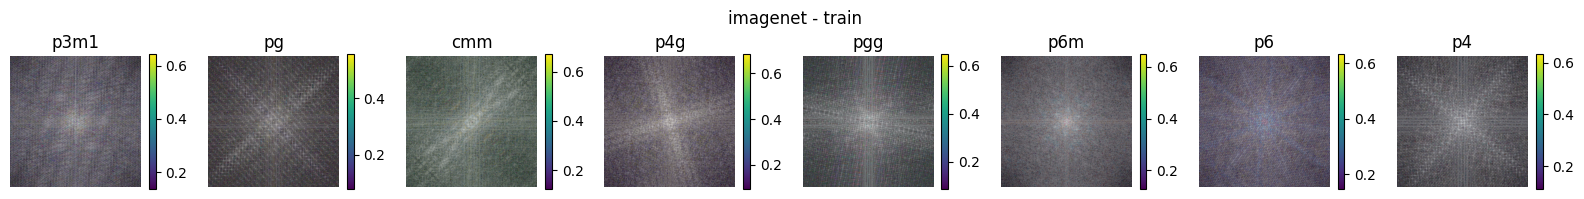

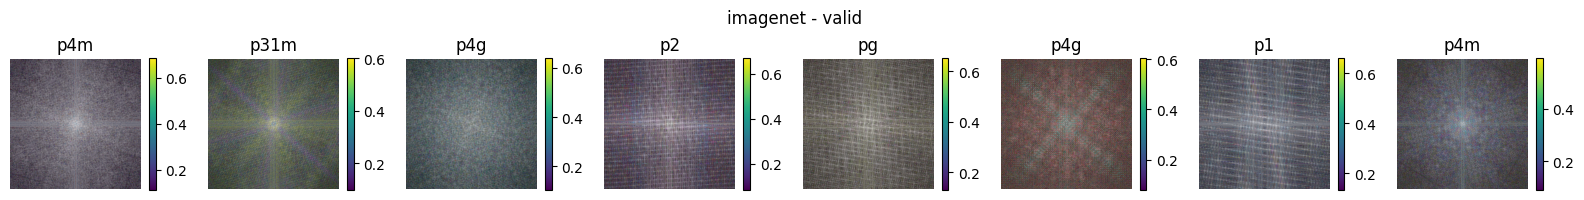

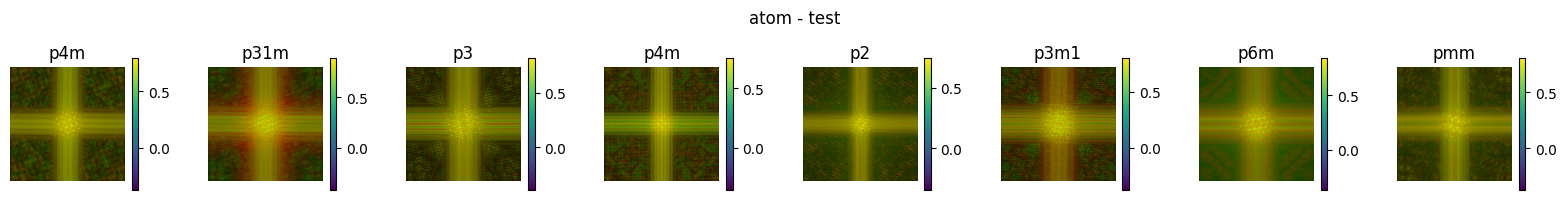

In [2]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)
transform = transforms.Compose([transforms.ToTensor()])
 
# imagenet
train_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_fft.h5', folder='imagenet', transform=transforms.ToTensor(),
                        data_key='magnitude_spectrum', label_key='labels')
train_dl = DataLoader(train_ds, batch_size=600, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train', show_colorbar=True)

# imagenet
valid_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_fft.h5', folder='imagenet', transform=transforms.ToTensor(),
                        data_key='magnitude_spectrum', label_key='labels')
valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid', show_colorbar=True)

# atom
test_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_fft.h5', folder='atom', transform=transforms.ToTensor(),
                       data_key='magnitude_spectrum', label_key='labels')
test_dl = DataLoader(test_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(test_dl, label_converter=label_converter, title='atom - test', show_colorbar=True)

In [3]:
model = resnet50_yichen(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


torch.Size([2, 17])


In [4]:
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'preprocess-fft_magnitude_spectrum'

In [5]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, save_code=True, config=config, group='preprocess')
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [6]:
device = torch.device('cuda:9')
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


  0%|          | 0/167 [00:00<?, ?it/s]

100%|██████████| 167/167 [02:26<00:00,  1.14it/s]


Training: Loss: 2.9945, Accuracy: 7.4200%, Time: 2.4424mins


100%|██████████| 167/167 [00:56<00:00,  2.97it/s]


...

Training: Loss: 0.0011, Accuracy: 99.9970%, Time: 2.3869mins


100%|██████████| 167/167 [00:57<00:00,  2.92it/s]


Validation : Loss : 0.0001, Accuracy: 99.9990%, Time: 0.95mins


100%|██████████| 167/167 [00:57<00:00,  2.92it/s]


Validation : Loss : 7.6313, Accuracy: 6.5120%, Time: 0.95mins


# FFT - phase_spectrum datasets

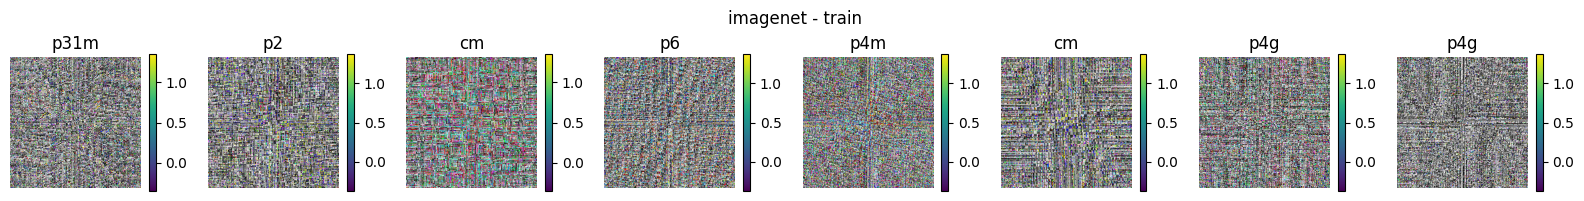

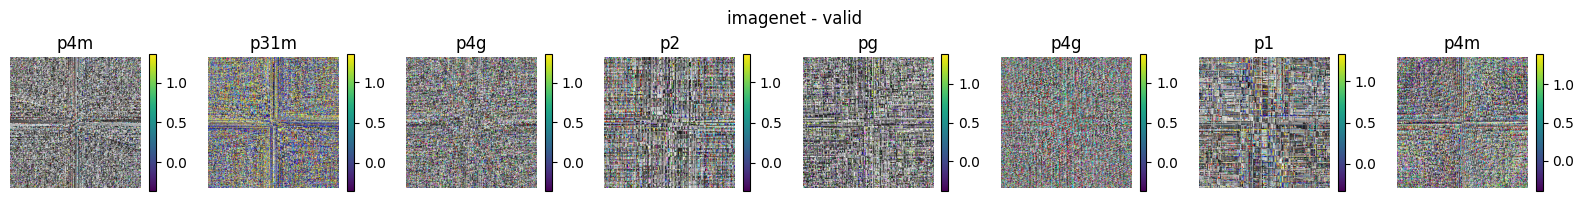

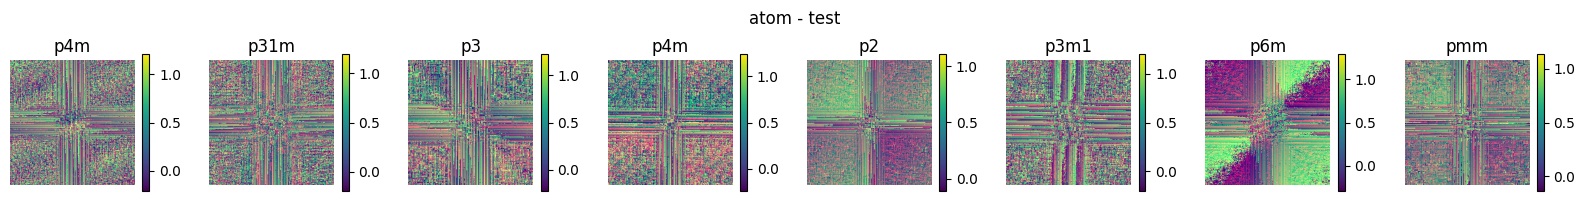

In [ ]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
train_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_fft.h5', folder='imagenet', transform=transforms.ToTensor(),
                        data_key='phase_spectrum', label_key='labels')
train_dl = DataLoader(train_ds, batch_size=600, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train', show_colorbar=True)

# imagenet
valid_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_fft.h5', folder='imagenet', transform=transforms.ToTensor(),
                        data_key='phase_spectrum', label_key='labels')
valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid', show_colorbar=True)

# atom
test_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_fft.h5', folder='atom', transform=transforms.ToTensor(),
                       data_key='phase_spectrum', label_key='labels')
test_dl = DataLoader(test_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(test_dl, label_converter=label_converter, title='atom - test', show_colorbar=True)

In [ ]:
model = resnet50_yichen(in_channels=3, n_classes=17)
outputs = model(torch.randn(2,3,256,256))
print(outputs.shape)

/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


torch.Size([2, 17])


In [ ]:
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'preprocess-fft_phase_spectrum'

In [ ]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config, group='preprocess')
config = wandb.config

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yig319. Use `wandb login --relogin` to force relogin


In [ ]:
device = torch.device('cuda:9')
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


  0%|          | 0/167 [00:00<?, ?it/s]

100%|██████████| 167/167 [02:22<00:00,  1.17it/s]


Training: Loss: 2.8456, Accuracy: 9.7700%, Time: 2.3793mins


100%|██████████| 167/167 [00:56<00:00,  2.97it/s]


...

Training: Loss: 0.0089, Accuracy: 99.9600%, Time: 2.3925mins


100%|██████████| 167/167 [00:57<00:00,  2.90it/s]


Validation : Loss : 0.0007, Accuracy: 99.9970%, Time: 0.96mins


100%|██████████| 167/167 [00:57<00:00,  2.91it/s]


Validation : Loss : 8.5165, Accuracy: 9.0810%, Time: 0.96mins


# radon

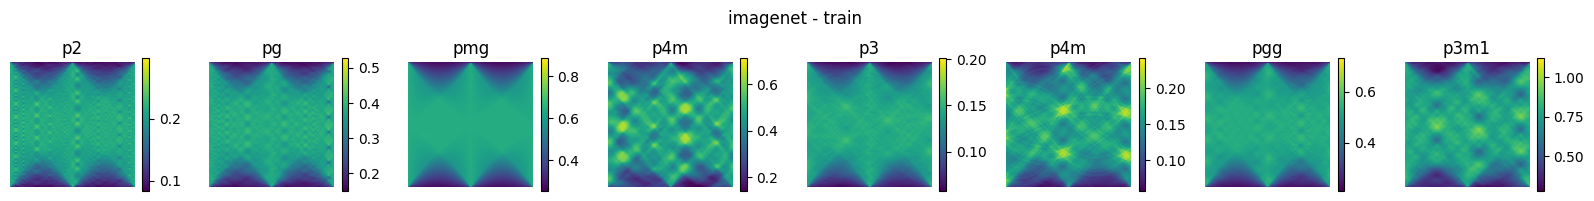

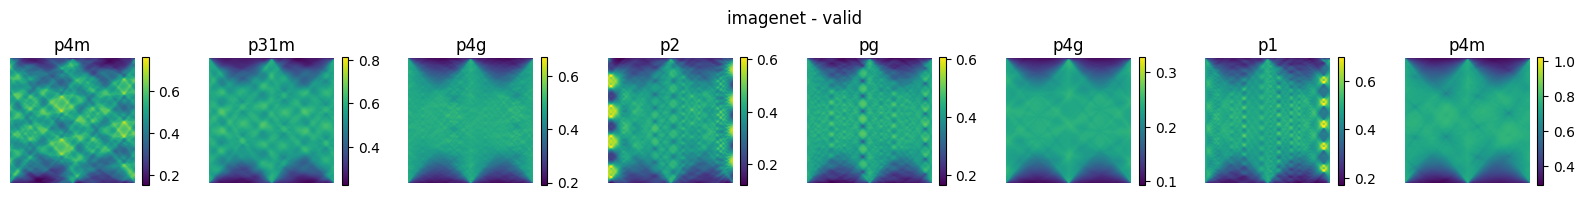

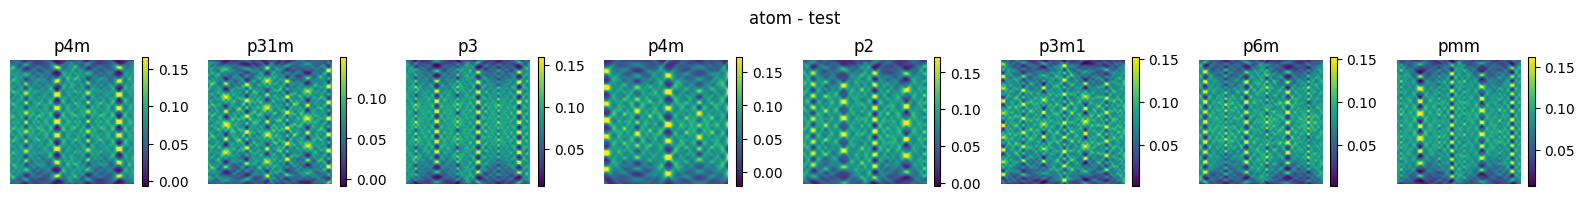

In [ ]:
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# imagenet
train_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_radon.h5', folder='imagenet', transform=transforms.ToTensor(),
                        data_key='radon', label_key='labels')
train_dl = DataLoader(train_ds, batch_size=600, shuffle=True, num_workers=4)
viz_dataloader(train_dl, label_converter=label_converter, title='imagenet - train', show_colorbar=True)

# imagenet
valid_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_radon.h5', folder='imagenet', transform=transforms.ToTensor(),
                        data_key='radon', label_key='labels')
valid_dl = DataLoader(valid_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(valid_dl, label_converter=label_converter, title='imagenet - valid', show_colorbar=True)

# atom
test_ds = hdf5_dataset('../../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset_radon.h5', folder='atom', transform=transforms.ToTensor(),
                       data_key='radon', label_key='labels')
test_dl = DataLoader(test_ds, batch_size=600, shuffle=False, num_workers=4)
viz_dataloader(test_dl, label_converter=label_converter, title='atom - test', show_colorbar=True)

In [ ]:
model = resnet50_yichen(in_channels=1, n_classes=17)
outputs = model(torch.randn(2,1,256,256))
print(outputs.shape)

torch.Size([2, 17])


In [ ]:
config = {
    'dataset': '10 million datasets - 100k subset',
    'loss_func': 'CrossEntropyLoss', # nn.MSELoss()
    'optimizer': 'Adam',
    'scheduler': 'OneCycleLR',
}

NAME = 'preprocess-radon'

In [ ]:
wandb.login()

proj_name = 'Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning'
wandb.init(project=proj_name, entity='yig319', name=NAME, id=NAME, save_code=True, config=config, group='preprocess')
config = wandb.config

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
test_acc,▁▁▂▄▄▅▆▆▄▄▅▄▅▆▅▂▅▃▇▂▄▆▂██▇▅▃▅▆▇▆▇▆▆▇▆▆▆▆
test_loss,▂▂▃▂▂▂▁▂▃▃▃▃▃▄▃█▃▄▂▄▄▄▅▃▄▅▄▅▆▆▅▆▆▆▆▆▆▆▆▆
train_acc,▁▁▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▇▆▇▇▇▇████████████
train_loss,██▇▆▆▅▅▄▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
valid_acc,▁▁▂▁▃▁▁▃▁▂▁▁▄▁▁▅▁▃▁▅▃▁▄▆▁▅▁▇▅▁█▁▁█▁█▁▁█▁
valid_loss,▅▄▃▄▂▅▄▃▅▄▅▅▂▆▅▂▅▃▅▂▄▆▃▂▆▂▆▁▂█▁▇█▁█▁██▁█
epoch,49
test_acc,0.09081
test_loss,8.51646
train_acc,0.9996


In [ ]:
device = torch.device('cuda:9')
lr = 1e-3
start = 0
epochs = 50

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))

history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, test_dl, epochs=epochs, start=start, 
                       scheduler=scheduler, model_dir=f'../../../saved_models/{NAME}/', tracking=True)

Epoch: 1/50


  0%|          | 0/167 [00:00<?, ?it/s]

100%|██████████| 167/167 [02:09<00:00,  1.29it/s]


Training: Loss: 3.0328, Accuracy: 6.3110%, Time: 2.1560mins


100%|██████████| 167/167 [00:41<00:00,  4.02it/s]


...

Training: Loss: 0.0010, Accuracy: 99.9930%, Time: 2.1525mins


100%|██████████| 167/167 [00:42<00:00,  3.93it/s]


Validation : Loss : 0.0002, Accuracy: 99.9960%, Time: 0.71mins


100%|██████████| 167/167 [00:42<00:00,  3.90it/s]


Validation : Loss : 5.8760, Accuracy: 34.6330%, Time: 0.71mins


# analyze

In [8]:
sys.path.append('../../../src/benchmark/')
from prediction_analysis import confusion_matrix, plot_cm

In [ ]:
model = torch.load('../../../saved_models/')

NAME = '05312023-benchmark-resnet50_from_scratch-v4_10m'
symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 
                    'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']                  

In [ ]:
device = torch.device('cuda:0')

cm = confusion_matrix(model, train_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-train_cm.npy', cm)

  0%|          | 0/16667 [00:00<?, ?it/s]

100%|██████████| 16667/16667 [1:50:41<00:00,  2.51it/s] 


Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,588308.0,588239.0,588239.0,588233.0,588232.0,588231.0,588236.0,588232.0,588239.0,588237.0,588238.0,588239.0,588239.0,588224.0,588239.0,588238.0,588237.0


Accuracy for these batches: 0.9996343029255766



ImageNet Symmetry Dataset


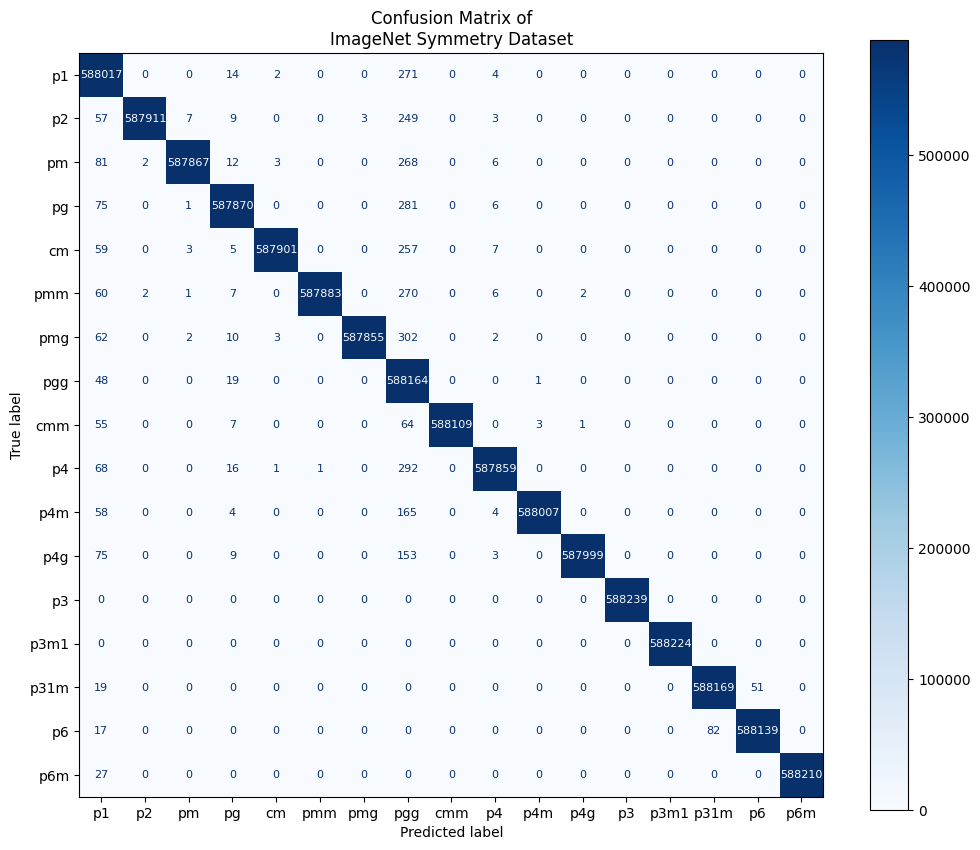

In [ ]:
# cm = np.load('11172021-benchmark_atom-fpn_spatial-transfer_learning-train.npy')

plot_cm(cm, symmetry_classes, file_path=f'{NAME}-train_cm', title='\nImageNet Symmetry Dataset', style='simple', font_size=8)
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, valid_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-valid_cm.npy', cm)

100%|██████████| 3334/3334 [20:58<00:00,  2.65it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,117670.0,117647.0,117647.0,117647.0,117646.0,117646.0,117648.0,117647.0,117647.0,117646.0,117647.0,117648.0,117647.0,117645.0,117645.0,117646.0,117647.0


Accuracy for these batches: 0.9991440068479452



ImageNet Symmetry Dataset


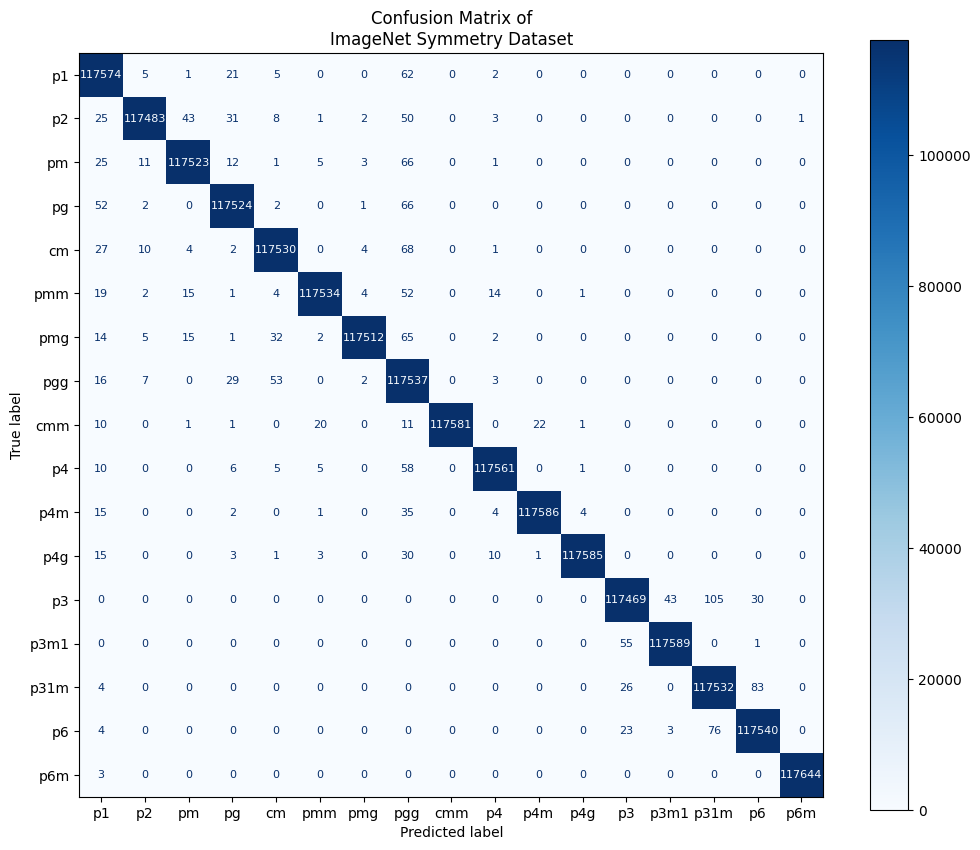

In [ ]:
# cm = np.load('11172021-benchmark_imagenet-fpn_spatial-transfer_learning-valid.npy')

plot_cm(cm, symmetry_classes, file_path=f'{NAME}-valid_cm', title='\nImageNet Symmetry Dataset', style='simple', font_size=8)
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')

In [ ]:
cm = confusion_matrix(model, test_dl, symmetry_classes, device, n_batches='all')
np.save(NAME+'-test_cm.npy', cm)

  0%|          | 0/3388 [00:00<?, ?it/s]

100%|██████████| 3388/3388 [20:49<00:00,  2.71it/s]

Sum for true labels:


,p1,p2,pm,pg,cm,pmm,pmg,pgg,cmm,p4,p4m,p4g,p3,p3m1,p31m,p6,p6m
0,270351.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0,110143.0


Accuracy for these batches: 0.5793104432218411



Atom Symmetry Dataset


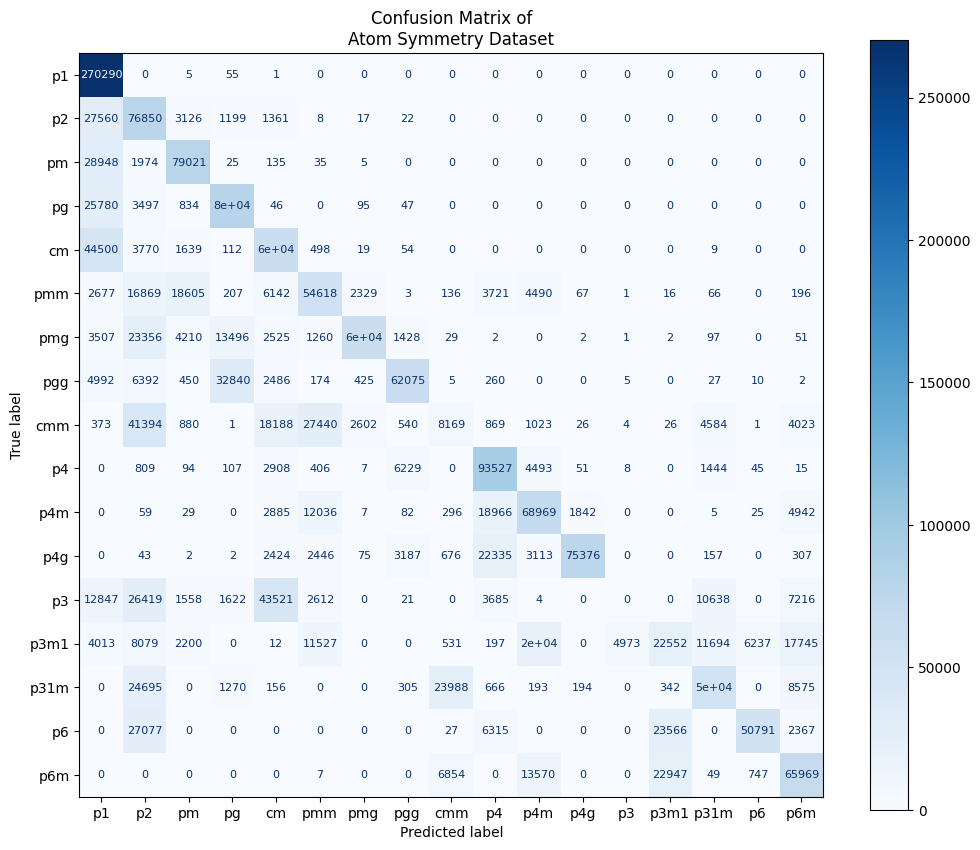

In [ ]:
# cm = np.load('05232022-benchmark-resnet50_from_scratch-dataset_v3-test.npy')

plot_cm(cm, symmetry_classes, file_path=f'{NAME}-test_cm', title='\nAtom Symmetry Dataset', style='simple', font_size=8)
# plot_cm(cm, symmetry_classes, save_file=None, style='with_axis')